In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Exercise 1: Logistic Regression on a Toy 2D Dataset

1. Generate two Gaussian clusters in $\mathbb{R}^2$ and associate them with a class depending on which cluster each point lies on, e.g.:
   - Class 0 centered at $(-2, -2)$ with variance $1$,
   - Class 1 centered at $(2, 2)$ with variance $0.5$.

2. Plot the dataset in 2D using `plt.scatter` so that each cluster is colored according to its class.

3. Implement logistic regression **from scratch** as did during class:
   
   $$
   f_\Theta(x) = \sigma(\Theta^T x),
   \qquad 
   \ell(\Theta; x,y)= -\big[y\log f_\Theta(x) + (1-y)\log(1 - f_\Theta(x))\big].
   $$


4. Train it using simple Gradient Descent on the full dataset. **Note:** the computation of $\nabla \mathcal{L}(\Theta; X, Y)$ for this choice of $\ell$ is given in the teaching note.

5. Visualize the learned **decision boundary**:
   - plot the line $\{\Theta^T x = 0\}$,
   - overlay with the dataset.

6. Comment on why the decision boundary is linear.

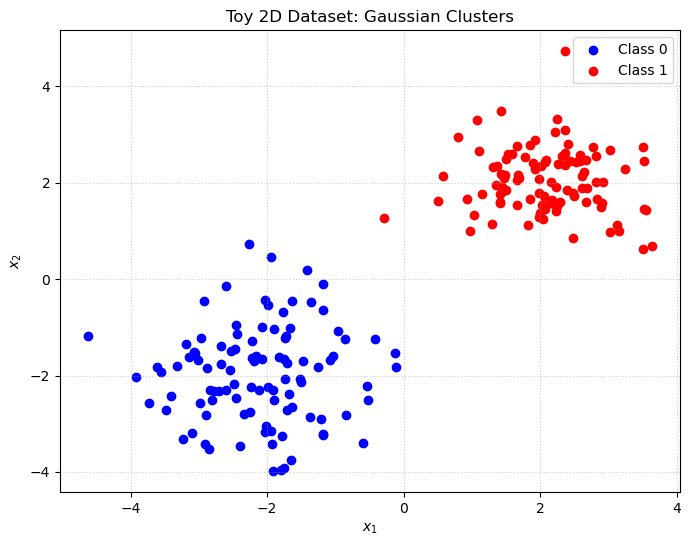

In [2]:
# --- 1. Data Generation ---

# Set random seed for reproducibility
np.random.seed(42)

# Parameters
N_samples = 100

# Class 0: Centered at (-2, -2), Variance 1
X0 = np.random.normal(loc=-2, scale=1.0, size=(N_samples, 2))
y0 = np.zeros((N_samples, 1))

# Class 1: Centered at (2, 2), Variance 0.5 (scale = sqrt(0.5))
X1 = np.random.normal(loc=2, scale=np.sqrt(0.5), size=(N_samples, 2))
y1 = np.ones((N_samples, 1))

# Combine datasets into a single matrix
X_raw = np.vstack((X0, X1))
y = np.vstack((y0, y1))

# Plot the dataset
plt.figure(figsize=(8, 6))
plt.scatter(X0[:, 0], X0[:, 1], color='blue', label='Class 0')
plt.scatter(X1[:, 0], X1[:, 1], color='red', label='Class 1')
plt.title('Toy 2D Dataset: Gaussian Clusters')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [3]:
# --- 2. Helper Functions ---

def sigmoid(z):
    # Compute the sigmoid function: 1 / (1 + exp(-z))
    # np.where is used to prevent overflow for large negative values of z
    return np.where(z >= 0, 1/(1+np.exp(-z)), np.exp(z)/(1+np.exp(z)))

def compute_cost(X, y, theta):
    # Compute Binary Cross Entropy Cost
    m = len(y)
    h = sigmoid(X @ theta) # Hypothesis
    
    # Epsilon added for numerical stability inside log() to avoid log(0)
    epsilon = 1e-5
    cost = (-1/m) * np.sum(y * np.log(h + epsilon) + (1 - y) * np.log(1 - h + epsilon))
    return cost

def train_logistic_regression(X_raw, y, eta=0.1, n_iters=1000):
    # 1. Add Bias Term (Intercept) by appending a column of ones
    m = X_raw.shape[0]
    X = np.c_[np.ones((m, 1)), X_raw] 
    
    # 2. Initialize parameters Theta to zeros
    theta = np.zeros((X.shape[1], 1))
    cost_history = []
    
    # 3. Gradient Descent Loop
    for i in range(n_iters):
        # Forward pass: compute linear combination and apply activation
        z = X @ theta
        h = sigmoid(z)
        
        # Backward pass: Compute gradient
        # Gradient formula: (1/m) * X^T * (h - y)
        gradient = (1/m) * X.T @ (h - y)
        
        # Update parameters
        theta -= eta * gradient
        
        # Store cost for visualization
        cost_history.append(compute_cost(X, y, theta))
        
    return theta, cost_history

# --- 3. Training ---
theta_opt, costs = train_logistic_regression(X_raw, y, eta=0.1, n_iters=1000)

print(f"Learned Parameters: \nIntercept (Theta_0): {theta_opt[0][0]:.4f}")
print(f"Weights (Theta_1, Theta_2): {theta_opt[1][0]:.4f}, {theta_opt[2][0]:.4f}")

Learned Parameters: 
Intercept (Theta_0): -0.1839
Weights (Theta_1, Theta_2): 1.9640, 1.8193


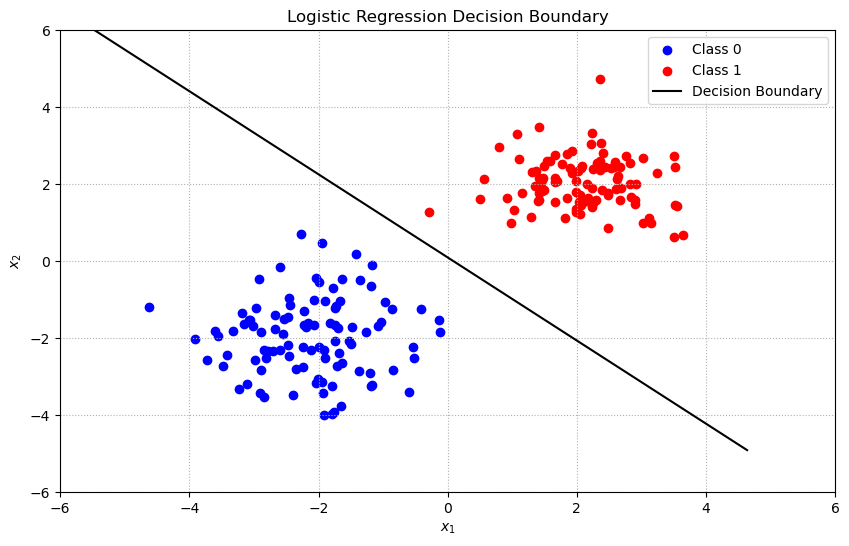

In [4]:
# --- 4. Decision Boundary Visualization ---

plt.figure(figsize=(10, 6))

# Plot scatter points
plt.scatter(X0[:, 0], X0[:, 1], color='blue', label='Class 0')
plt.scatter(X1[:, 0], X1[:, 1], color='red', label='Class 1')

# Calculate the decision boundary line
# The boundary is where Theta^T * x = 0
# Theta_0 + Theta_1 * x1 + Theta_2 * x2 = 0
# Solving for x2: x2 = -(Theta_0 + Theta_1 * x1) / Theta_2

# Define x1 range for the plot line
x1_vals = np.array([np.min(X_raw[:, 0]) - 1, np.max(X_raw[:, 0]) + 1])
theta_0 = theta_opt[0][0]
theta_1 = theta_opt[1][0]
theta_2 = theta_opt[2][0]

# Compute corresponding x2 values
x2_vals = -(theta_0 + theta_1 * x1_vals) / theta_2

# Plot the line
plt.plot(x1_vals, x2_vals, 'k-', label='Decision Boundary')

plt.title('Logistic Regression Decision Boundary')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.legend()
plt.grid(True, linestyle=':')
plt.xlim(-6, 6)
plt.ylim(-6, 6)
plt.show()

In [ ]:
'''
El objetivo es implementar y entrenar un clasificador de Regresión Logística desde cero (sin usar sklearn) para distinguir 
entre dos grupos de puntos (clústeres) generados artificialmente en un plano 2D.


Pregunta: Explica la función de hipótesis y por qué usamos la Sigmoide.
Respuesta: "La regresión logística modela la probabilidad $P(y=1|x)$. Usamos la función Sigmoide porque comprime cualquier 
valor real de entrada (desde $-\infty$ a $+\infty$) a un rango válido de probabilidad $(0, 1)$."


Pregunta: ¿Por qué la frontera de decisión (decision boundary) es LINEAL?
Respuesta: "La frontera de decisión es el lugar donde el clasificador está indeciso, es decir, donde la probabilidad es 0.5.
La función sigmoide vale 0.5 exactamente cuando su entrada es 0 ($\sigma(0) = 0.5$).
La entrada de la sigmoide es nuestra combinación lineal $\Theta^T x$.
Por tanto, la frontera está definida por la ecuación $\Theta^T x = 0$.
Desarrollando esto en 2D: $\Theta_0 + \Theta_1 x_1 + \Theta_2 x_2 = 0$. Esta es la ecuación de una línea recta. 
Por eso la regresión logística es un clasificador lineal."
'''

## Exercise 2: SGD on Logistic Regression

Use the same synthetic dataset used in the previous exercise, but train logistic regression using **SGD** with the following choices:

1. Try different batch sizes:
   - $N_{\text{batch}} = 1$,
   - $N_{\text{batch}} = 10$,
   - $N_{\text{batch}} = N$ (full GD).

2. For each setting:
   - Plot the loss vs epoch,
   - Plot the classification accuracy vs epoch.

3. Compare the stability and speed of convergence over the choice of different batch sizes.

4. Why the gradients become noisier for small batches? Why larger batches give smoother curves?

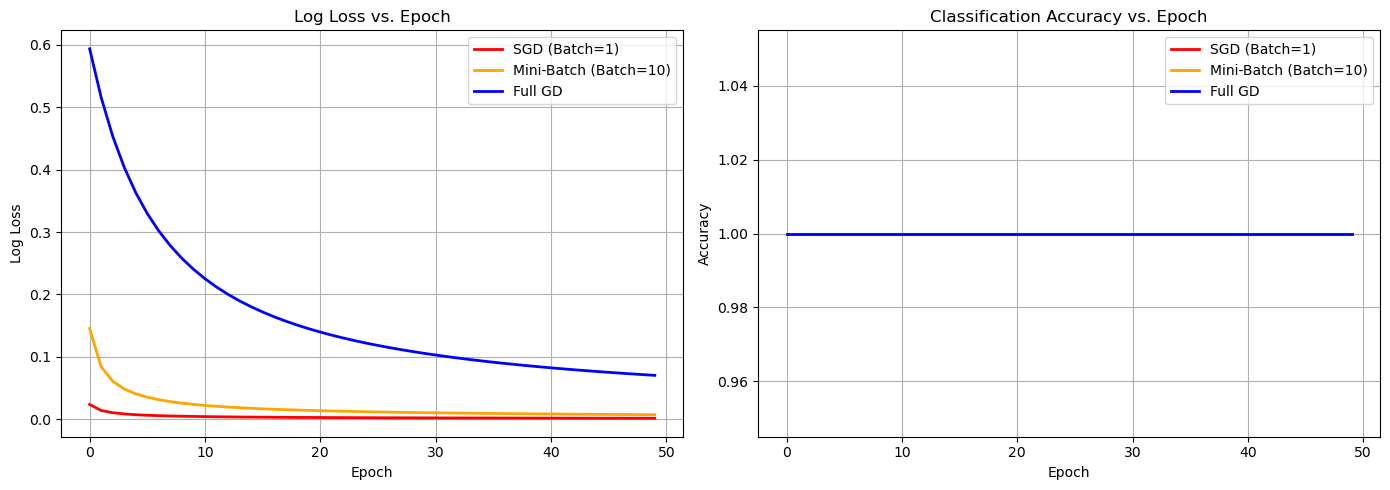

In [5]:
# --- 1. Helper Functions for SGD ---

def compute_metrics(X, y, theta):
    # Computes both Loss and Accuracy on the provided dataset
    h = sigmoid(X @ theta)
    
    # Loss
    epsilon = 1e-5
    loss = (-1/len(y)) * np.sum(y * np.log(h + epsilon) + (1 - y) * np.log(1 - h + epsilon))
    
    # Accuracy: Predictions >= 0.5 are class 1
    acc = ((h >= 0.5).astype(int) == y).mean()
    return loss, acc

def train_logistic_sgd(X_raw, y, batch_size, eta=0.1, epochs=30):
    # Add bias term
    m = X_raw.shape[0]
    X = np.c_[np.ones((m, 1)), X_raw]
    
    # Initialize parameters
    theta = np.zeros((X.shape[1], 1))
    
    loss_history = []
    acc_history = []
    
    for epoch in range(epochs):
        # Shuffle data indices at the start of each epoch
        indices = np.random.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]
        
        # Mini-batch Loop
        for i in range(0, m, batch_size):
            # Extract current batch
            X_batch = X_shuffled[i : i + batch_size]
            y_batch = y_shuffled[i : i + batch_size]
            
            # Compute Gradient on the batch
            m_batch = len(y_batch)
            h = sigmoid(X_batch @ theta)
            gradient = (1/m_batch) * X_batch.T @ (h - y_batch)
            
            # Update parameters
            theta -= eta * gradient
            
        # At the end of the epoch, compute metrics on the FULL dataset
        loss, acc = compute_metrics(X, y, theta)
        loss_history.append(loss)
        acc_history.append(acc)
        
    return loss_history, acc_history

# --- 2. Running the Experiment ---
batch_sizes = [1, 10, len(y)] # Test batch sizes: 1 (SGD), 10 (Mini-batch), N (Full GD)
labels = {1: 'SGD (Batch=1)', 10: 'Mini-Batch (Batch=10)', len(y): 'Full GD'}
colors = {1: 'red', 10: 'orange', len(y): 'blue'}

results = {}

# Run training for each batch size
for bs in batch_sizes:
    loss_hist, acc_hist = train_logistic_sgd(X_raw, y, batch_size=bs, eta=0.05, epochs=50)
    results[bs] = {'loss': loss_hist, 'acc': acc_hist}

# --- 3. Visualization ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Loss vs Epoch
for bs in batch_sizes:
    ax1.plot(results[bs]['loss'], label=labels[bs], color=colors[bs], linewidth=2)
ax1.set_title("Log Loss vs. Epoch")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Log Loss")
ax1.grid(True)
ax1.legend()

# Plot Accuracy vs Epoch
for bs in batch_sizes:
    ax2.plot(results[bs]['acc'], label=labels[bs], color=colors[bs], linewidth=2)
ax2.set_title("Classification Accuracy vs. Epoch")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
'''
En el ejercicio anterior usaste "Full Gradient Descent" (el gradiente estándar): calculabas el promedio de error de todos 
los puntos antes de mover la línea de decisión. Ahora, vas a entrenar el mismo clasificador pero actualizando los pesos 
frecuentemente usando Mini-batches (grupos pequeños de datos) o SGD puro (1 dato a la vez).


Pregunta: Compara la estabilidad y velocidad de convergencia según el tamaño del batch.
Respuesta (Velocidad): "En términos de 'épocas', el SGD (Batch=1) es explosivamente rápido al principio.


Pregunta: ¿Por qué los gradientes son más ruidosos con batches pequeños?
Respuesta: "Porque el gradiente calculado con 1 solo punto es una estimación con alta varianza del gradiente real.
Al no promediar con otros puntos, ese error individual se traduce directamente en un movimiento errático de los parámetros."
'''

## Exercise 3: Evaluation Metrics on a Synthetic Dataset

Using the logistic regression model trained above:

1. Compute predicted probabilities $\hat y_i = f_\Theta(x_i)$.
2. Convert them to binary predictions $\hat y_i \in \{0,1\}$ using threshold $0.5$.
3. Compute:
   - Confusion matrix (TP, FP, FN, TN),
   - Accuracy,
   - Precision,
   - Recall,
   - F1-score.

4. Modify the threshold to:
   - $0.3$,
   - $0.7$,
   and repeat.

5. Comment on:
   - How lower thresholds increase recall and lower precision,
   - How higher thresholds increase precision and reduce recall,
   - Why classification metrics depend on the application (as discussed in class).

In [6]:
# --- 1. Compute Predictions ---
np.random.seed(42)

N_samples = 100
X0 = np.random.normal(loc=-1.5, scale=1.0, size=(N_samples, 2))
X1 = np.random.normal(loc=1.5, scale=1.0, size=(N_samples, 2))

X_raw = np.vstack((X0, X1))
y = np.vstack((np.zeros((N_samples, 1)), np.ones((N_samples, 1))))

# Add bias term
m = X_raw.shape[0]
X = np.c_[np.ones((m, 1)), X_raw]


def sigmoid(z):
    return np.where(z >= 0, 1/(1+np.exp(-z)), np.exp(z)/(1+np.exp(z)))


def train_logistic_sgd(X, y, batch_size=10, eta=0.05, epochs=50):
    theta = np.zeros((X.shape[1], 1))
    m = len(y)

    for _ in range(epochs):
        indices = np.random.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for i in range(0, m, batch_size):
            X_batch = X_shuffled[i:i + batch_size]
            y_batch = y_shuffled[i:i + batch_size]

            h = sigmoid(X_batch @ theta)
            gradient = (1 / len(y_batch)) * X_batch.T @ (h - y_batch)
            theta -= eta * gradient

    return theta

theta_final = train_logistic_sgd(X, y)

# Compute probabilities
probs = sigmoid(X @ theta_final)

# --- 2. Metric Evaluation Function ---

def evaluate_metrics(y_true, y_probs, threshold):
    # Convert probabilities to binary class predictions based on threshold
    y_pred = (y_probs >= threshold).astype(int)
    
    # Calculate Confusion Matrix Components
    TP = np.sum((y_true == 1) & (y_pred == 1)) # True Positives
    TN = np.sum((y_true == 0) & (y_pred == 0)) # True Negatives
    FP = np.sum((y_true == 0) & (y_pred == 1)) # False Positives
    FN = np.sum((y_true == 1) & (y_pred == 0)) # False Negatives
    
    # Calculate derived metrics
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    
    # Handle division by zero for Precision/Recall/F1
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    
    return {
        "Threshold": threshold,
        "TP": TP, "TN": TN, "FP": FP, "FN": FN,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    }

# --- 3. Evaluation over Thresholds ---
thresholds = [0.3, 0.5, 0.7]
results = []

for t in thresholds:
    results.append(evaluate_metrics(y, probs, t))

# Display as DataFrame
df_metrics = pd.DataFrame(results)
cols = ["Threshold", "TP", "FP", "FN", "TN", "Accuracy", "Precision", "Recall", "F1-Score"]
print(df_metrics[cols].to_string(index=False))

 Threshold  TP  FP  FN  TN  Accuracy  Precision  Recall  F1-Score
       0.3  99   2   1  98     0.985   0.980198    0.99  0.985075
       0.5  99   0   1 100     0.995   1.000000    0.99  0.994975
       0.7  97   0   3 100     0.985   1.000000    0.97  0.984772


In [ ]:
'''
Una vez entrenado el modelo, este no devuelve "Clase 0" o "Clase 1", sino una probabilidad (ej. 0.8, 0.45).
Para tomar una decisión final, necesitas un umbral de corte (threshold). 
Normalmente usamos 0.5: Si $p \ge 0.5$ es Clase 1, si no, Clase 0.En este ejercicio mueves ese umbral a 0.3 
(más permisivo) y 0.7 (más estricto) para ver cómo cambian los errores:


Pregunta: ¿Cómo afecta bajar el umbral (0.3) al Recall y la Precisión?
Respuesta: "Al bajar el umbral a 0.3, el modelo se vuelve más 'optimista' o agresivo prediciendo la Clase 1.
Efecto en Recall (Sube): Como es más fácil pasar el corte, detectamos casi todos los positivos reales 
(menos Falsos Negativos).
Efecto en Precisión (Baja): Al aceptar tantos positivos, inevitablemente se cuelan más 'intrusos' 
(Falsos Positivos), por lo que la pureza de nuestras predicciones positivas disminuye."


Pregunta: ¿Cómo afecta subir el umbral (0.7) al Recall y la Precisión?
Respuesta: "Al subir el umbral a 0.7, el modelo se vuelve conservador o exigente. Solo dice 'Clase 1' 
si está muy seguro.
Efecto en Precisión (Sube): Si el modelo dice 'Positivo', es casi seguro que es verdad 
(mínimos Falsos Positivos).
Efecto en Recall (Baja): Al ser tan exigente, se nos escapan muchos casos positivos reales que tenían 
probabilidad media (ej. 0.6), aumentando los Falsos Negativos."


Pregunta: ¿Por qué las métricas dependen de la aplicación?
Respuesta: "Porque no todos los errores cuestan lo mismo."
Caso Médico (Cáncer): "Queremos Alto Recall. Es vital no decirle a un enfermo que está sano 
(Falso Negativo es fatal).
'''

## Exercise 4: Logistic Regression on a Real Dataset

Reproduce the pipeline from the book using the **Pima Indians Diabetes Dataset**, available at https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database.

This dataset contains medical measurements and a binary label indicating diabetes diagnosis.

1. Preprocess the data as done in class:
   - Download `diabetes.csv`.
   - Extract features $X$ and labels $y$.
   - **Standardize the features** (mean 0, variance 1).  
      Explain why normalization is required, connecting to:
      - conditioning,
      - stable optimization,
      - meaningful gradient magnitudes.

   - Add a bias column of 1s.

2. Implement logistic regression from scratch (sigmoid + BCE + gradient), and optimize using **SGD** with: 
   - a batch size of 32, a learning rate of $10^{-3}$, and 200 epochs.
   - for each epoch, track full-dataset BCE loss and full-dataset accuracy.
   - in a plot, visualize the behavior of Loss vs epoch and Accuracy vs epoch. Comment the results.

3. Train the same model using **Adam** (using the formulas from class):
   
   $$
   \Theta_{k+1} = \Theta_k - \eta \frac{\hat m_k}{\sqrt{\hat v_k} + \epsilon}.
   $$

   with a learning rate of $10^{-3}$, a batch size of 32, and 200 epochs. Then, plot SGD vs Adam loss and accuracy curves.

4. For each method, evaluate:
   - Final accuracy,
   - Confusion matrix,
   - Precision, Recall, F1.

5. Discuss on which method converge faster, which oscillate more, and how this relates to adaptive learning rates discussed in class.

In [7]:
# --- 1. Data Loading ---
df = pd.read_csv('diabetes.csv')

# Split features and target
X_raw = df.drop('Outcome', axis=1).values
y = df['Outcome'].values.reshape(-1, 1)

# --- 2. Standardization ---
# Center mean to 0 and scale variance to 1
mean = np.mean(X_raw, axis=0)
std = np.std(X_raw, axis=0)
std[std == 0] = 1.0 # Prevent division by zero
X_scaled = (X_raw - mean) / std

# Add bias term
m = X_scaled.shape[0]
X = np.c_[np.ones((m, 1)), X_scaled]

print(f"Data Shape: {X.shape}")
print(f"First row (Standardized): {X[0]}")

Data Shape: (768, 9)
First row (Standardized): [ 1.          0.63994726  0.84832379  0.14964075  0.90726993 -0.69289057
  0.20401277  0.46849198  1.4259954 ]


Training SGD...
Training Adam...


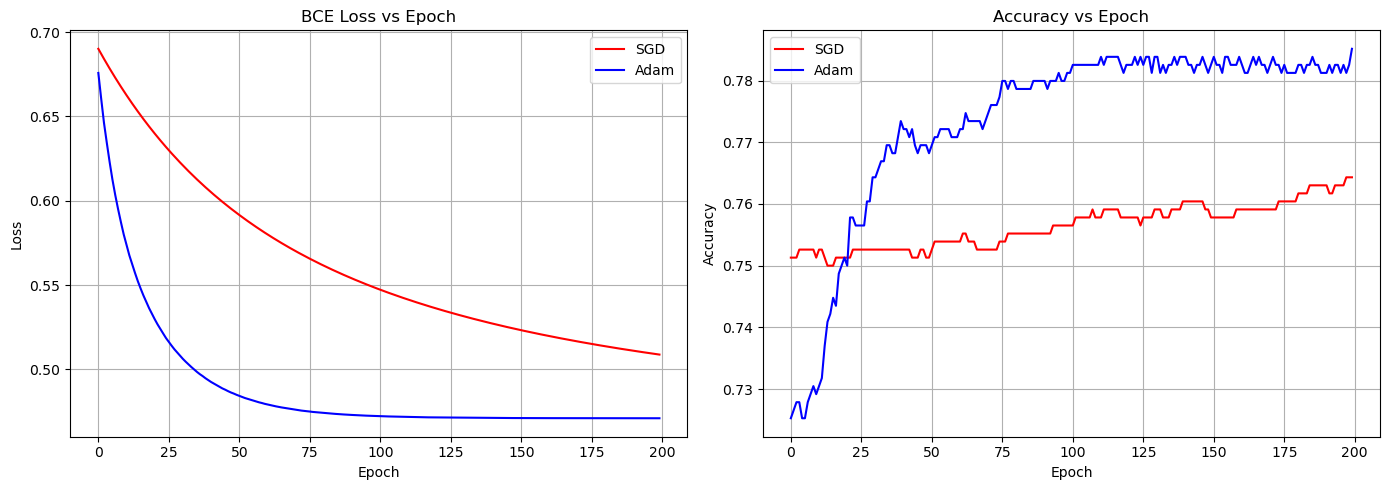

In [8]:
# --- Helper Functions ---
def sigmoid(z):
    return np.where(z >= 0, 1/(1+np.exp(-z)), np.exp(z)/(1+np.exp(z)))


# --- 3. Optimizer Implementation ---

def get_batch_gradient(X_batch, y_batch, theta):
    # Computes gradient for a given batch
    m_b = len(y_batch)
    h = sigmoid(X_batch @ theta)
    return (1/m_b) * X_batch.T @ (h - y_batch)

def compute_loss_acc(X, y, theta):
    # Computes metrics on the full dataset
    m = len(y)
    h = sigmoid(X @ theta)
    epsilon = 1e-8
    loss = (-1/m) * np.sum(y * np.log(h + epsilon) + (1 - y) * np.log(1 - h + epsilon))
    preds = (h >= 0.5).astype(int)
    acc = np.mean(preds == y)
    return loss, acc

# SGD Optimizer
def train_sgd(X, y, lr=1e-3, batch_size=32, epochs=200):
    m, n = X.shape
    theta = np.zeros((n, 1))
    loss_hist = []
    acc_hist = []
    
    for epoch in range(epochs):
        indices = np.random.permutation(m)
        X_shuff = X[indices]
        y_shuff = y[indices]
        
        for i in range(0, m, batch_size):
            X_b = X_shuff[i:i+batch_size]
            y_b = y_shuff[i:i+batch_size]
            
            grad = get_batch_gradient(X_b, y_b, theta)
            theta -= lr * grad
            
        l, a = compute_loss_acc(X, y, theta)
        loss_hist.append(l)
        acc_hist.append(a)
        
    return theta, loss_hist, acc_hist

# Adam Optimizer
def train_adam(X, y, lr=1e-3, batch_size=32, epochs=200, beta1=0.9, beta2=0.999, eps=1e-8):
    m, n = X.shape
    theta = np.zeros((n, 1))
    
    # Initialize Adam moments
    m_t = np.zeros((n, 1)) # First moment estimate
    v_t = np.zeros((n, 1)) # Second raw moment estimate
    t = 0 # Time step
    
    loss_hist = []
    acc_hist = []
    
    for epoch in range(epochs):
        indices = np.random.permutation(m)
        X_shuff = X[indices]
        y_shuff = y[indices]
        
        for i in range(0, m, batch_size):
            t += 1
            X_b = X_shuff[i:i+batch_size]
            y_b = y_shuff[i:i+batch_size]
            
            g = get_batch_gradient(X_b, y_b, theta)
            
            # Update moments
            m_t = beta1 * m_t + (1 - beta1) * g
            v_t = beta2 * v_t + (1 - beta2) * (g**2)
            
            # Bias correction
            m_hat = m_t / (1 - beta1**t)
            v_hat = v_t / (1 - beta2**t)
            
            # Parameter update
            theta -= lr * m_hat / (np.sqrt(v_hat) + eps)
            
        l, a = compute_loss_acc(X, y, theta)
        loss_hist.append(l)
        acc_hist.append(a)
        
    return theta, loss_hist, acc_hist

# --- 4. Execution and Visualization ---
print("Training SGD...")
theta_sgd, loss_sgd, acc_sgd = train_sgd(X, y, lr=1e-3, batch_size=32, epochs=200)

print("Training Adam...")
theta_adam, loss_adam, acc_adam = train_adam(X, y, lr=1e-3, batch_size=32, epochs=200)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss Plot
ax1.plot(loss_sgd, label='SGD', color='red')
ax1.plot(loss_adam, label='Adam', color='blue')
ax1.set_title('BCE Loss vs Epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Accuracy Plot
ax2.plot(acc_sgd, label='SGD', color='red')
ax2.plot(acc_adam, label='Adam', color='blue')
ax2.set_title('Accuracy vs Epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [9]:
def get_metrics(X, y, theta, name):
    h = sigmoid(X @ theta)
    preds = (h >= 0.5).astype(int)
    
    TP = np.sum((y == 1) & (preds == 1))
    TN = np.sum((y == 0) & (preds == 0))
    FP = np.sum((y == 0) & (preds == 1))
    FN = np.sum((y == 1) & (preds == 0))
    
    acc = (TP + TN) / len(y)
    prec = TP / (TP + FP) if (TP + FP) > 0 else 0
    rec = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1 = 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0
    
    print(f"--- {name} Results ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"Confusion Matrix:\n[[TN={TN} FP={FP}]\n [FN={FN} TP={TP}]]\n")

get_metrics(X, y, theta_sgd, "SGD")
get_metrics(X, y, theta_adam, "Adam")

--- SGD Results ---
Accuracy:  0.7643
Precision: 0.6883
Recall:    0.5933
F1 Score:  0.6373
Confusion Matrix:
[[TN=428 FP=72]
 [FN=109 TP=159]]

--- Adam Results ---
Accuracy:  0.7852
Precision: 0.7441
Recall:    0.5858
F1 Score:  0.6555
Confusion Matrix:
[[TN=446 FP=54]
 [FN=111 TP=157]]



In [ ]:
'''
Predecir si un paciente tiene diabetes (1) o no (0) basándote en medidas médicas (glucosa, presión arterial, BMI, edad, etc.). 
Lo importante aquí no es solo el modelo (que sigue siendo Regresión Logística), sino la comparación de optimizadores:
SGD: El "vainilla" o clásico. Tasa de aprendizaje fija.
Adam (Adaptive Moment Estimation): El estándar de oro en Deep Learning. Ajusta la velocidad de aprendizaje automáticamente 
para cada parámetro.


Pregunta: ¿Por qué es OBLIGATORIO normalizar (estandarizar) los datos aquí?
Respuesta: "Porque las características tienen escalas radicalmente distintas.
La Insulina puede valer 800, mientras que la función Pedigree vale 0.5.


Pregunta: Explica la intuición detrás de Adam y sus fórmulas.
Respuesta: "Adam combina dos grandes ideas:
Momentum ($m_t$): Acumula la velocidad de los pasos anteriores (como una bola de nieve rodando). 
Si el gradiente apunta siempre al mismo lado, acelera.
Resultado: Adam tiene un 'learning rate adaptativo' para cada peso individual. Acelera en las zonas planas y frena en las 
zonas inestables."


Pregunta: Compara las curvas de convergencia (SGD vs Adam) que has obtenido.
Respuesta: "Como se ve en las gráficas:
Adam (Curva Azul): Cae en picado muy rápido. En las primeras 10-20 épocas ya ha alcanzado una precisión alta. Esto es típico
de los métodos adaptativos; encuentran el camino rápido.
SGD (Curva Roja): Baja de forma más constante pero lenta. Necesita muchas más épocas para llegar al mismo nivel de error 
que Adam consigue al principio.


Pregunta: Discusión sobre las Métricas Finales (Accuracy vs F1).
Respuesta: "Aunque la Accuracy es decente (~78%), el F1-Score es más bajo (~0.65).
Esto sugiere que el dataset podría estar desbalanceado (hay más sanos que diabéticos) o que el modelo tiene dificultades 
para recuperar todos los casos positivos (Recall bajo ~0.58).
Adam logró un Accuracy final mayor (78.5%) que SGD (76.4%) en las mismas 200 épocas, demostrando su eficiencia."
'''